In [81]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

In [82]:
#Simulation vecteur de N gaussiennes réelles standards

def normal_standard(N) : 

    U = npr.random(N)
    V = npr.random(N)

    X = np.sqrt(-2 * np.log(U))*np.cos(2*np.pi*V)

    return X 

In [83]:
# Simulation d'un mouvement brownien standard
def mouvement_brownien(T, N):
    """
    Simule une trajectoire d'un mouvement brownien standard.
    Paramètres :
    - T : temps final
    - N : nombre de pas de temps

    Retourne :
    - t : tableau des temps
    - W : tableau des valeurs du mouvement brownien
    """

    dt = T / N
    t = np.linspace(0, T, N+1)
    W = np.zeros(N+1)

    dW = np.sqrt(dt) * normal_standard(N)

    for i in range(1, N+1):
        W[i] = W[i-1] + dW[i-1]

    return t, W

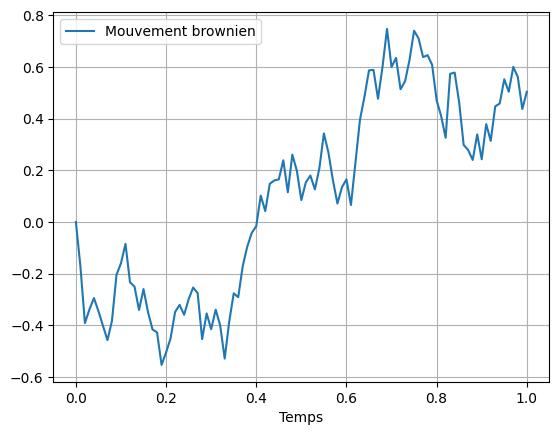

In [84]:
# Test 

t, W = mouvement_brownien(1, 100)

# Affichage
plt.plot(t, W, label='Mouvement brownien')
plt.xlabel('Temps')
plt.legend()
plt.grid()
plt.show()

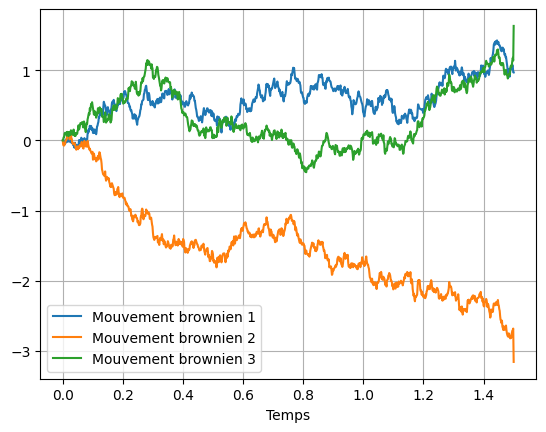

In [85]:
# Simulation des trajectoires Mouvement Bornien Standards Corrélés
T = 1.5   # Temps final
N = 1000  # Nombre de pas de temps
rho = 0.3
Gamma = np.linalg.cholesky([[1,rho,rho],
                            [rho,1,rho],
                            [rho,rho,1]])
# 1 : Simulation MB standards de dimension 3
t1, W1 = mouvement_brownien(T, N) # t1 : subdivisions de 0, 1.5
_, W2 = mouvement_brownien(T, N)
_, W3 = mouvement_brownien(T, N)

# 2 : corrélation des MB : 
for i in range (0, N):
    [W1[i],W2[i],W3[i]] = Gamma @ [W1[i],W2[i],W3[i]]
    
# Affichage
plt.plot(t1, W1, label='Mouvement brownien 1')
plt.plot(t1, W2, label='Mouvement brownien 2')
plt.plot(t1, W3, label='Mouvement brownien 3')
plt.xlabel('Temps')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Simulation de P1 par la méthode de Monte Carlo

def LGN_uniforme(N) :
    """
    Simule l'esperance d'une suite de v.a. iid.
    Paramètres :
    - X : vecteur de v.a. 
    - T : temps final
    - N : nombre de pas de temps

    Retourne :
    - E : Esperance des (Xi)i à une précision 1/sqrt(N)
    """

    U = np.random.uniform(0, 1, N) # génère N v.a. uniformes sur [0,1] (à priori iid)

    return (1/N) * np.sum(U)

In [ ]:
# test
N = 10000000
LGN_uniforme(N)

# on a bien une précision à ~10^-4 :D

np.float64(0.5000493160328925)